In [1]:
import pandas as pd

from src.data_loading import ID_COL, TARGET_COL, PROCESSED_DATA_PATH, load_data_with_secondary_tables
from src.models import make_lightGBM
from src.tuning import load_lgbm_params

application_train, application_test = load_data_with_secondary_tables()

X = application_train.drop(columns=[ID_COL, TARGET_COL])
y = application_train[TARGET_COL]
X_test = application_test.drop(columns=[ID_COL], errors="ignore")

best_lgbm_params = load_lgbm_params("best_lgbm_params.json")
final_model = make_lightGBM(lgbm_params=best_lgbm_params)
final_model.fit(X, y)

submission = pd.DataFrame(
    {
        ID_COL: application_test[ID_COL],
        TARGET_COL: final_model.predict_proba(X_test)[:, 1],
    }
)

submission_path = PROCESSED_DATA_PATH / "submission_lgbm_engineered.csv"
submission.to_csv(submission_path, index=False)

print(f"Saved submission to: {submission_path}")
submission.head()


Saved submission to: /Users/ryanyao/Quant Projects/Home_Credit/data/processed/submission_lgbm_engineered.csv


,SK_ID_CURR,TARGET
0,100001,0.042241
1,100005,0.160737
2,100013,0.048121
3,100028,0.038792
4,100038,0.128139


/Users/ryanyao/Quant Projects/Home_Credit/.venv/lib/python3.14/site-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


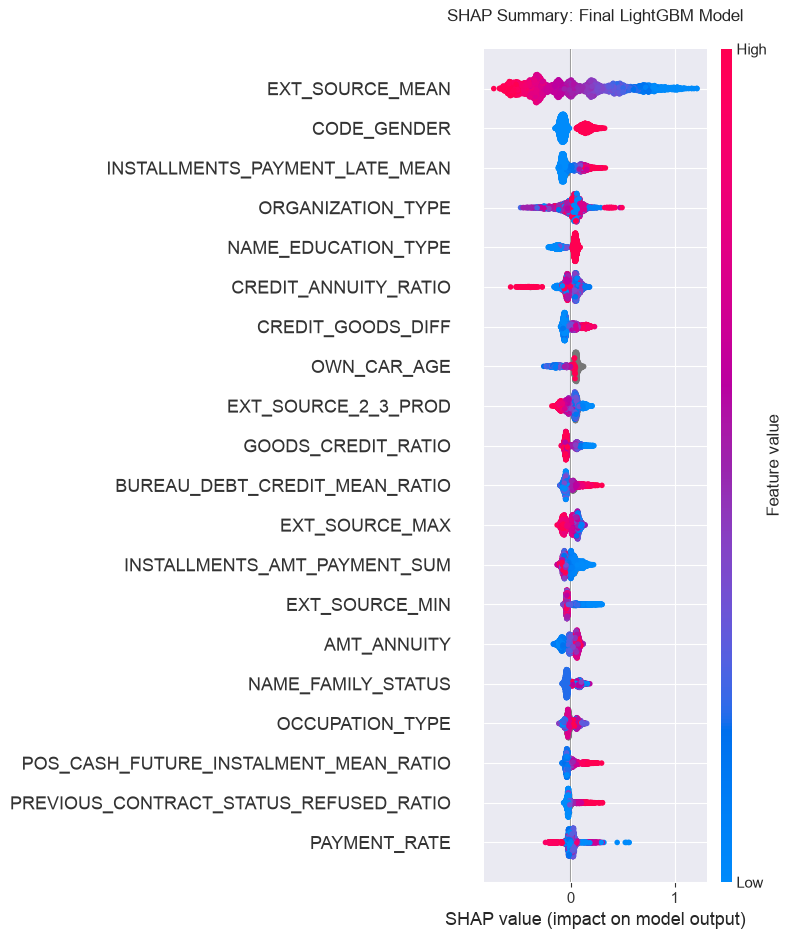

Saved SHAP summary plot to: /Users/ryanyao/Quant Projects/Home_Credit/data/processed/shap_summary_lgbm_engineered.png


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import shap

SHAP_SAMPLE_SIZE = 3_000
RANDOM_STATE = 42

shap_sample = X.sample(
    n=min(SHAP_SAMPLE_SIZE, len(X)),
    random_state=RANDOM_STATE,
)

preprocessor = final_model.named_steps["preprocess"]
lgbm_estimator = final_model.named_steps["model"]
X_shap = preprocessor.transform(shap_sample)

explainer = shap.TreeExplainer(lgbm_estimator)
shap_values = explainer.shap_values(X_shap, check_additivity=False)

if isinstance(shap_values, list):
    shap_values_for_plot = shap_values[1]
elif getattr(shap_values, "ndim", None) == 3:
    shap_values_for_plot = shap_values[:, :, 1]
else:
    shap_values_for_plot = shap_values

X_shap_plot = X_shap.copy()
for col in X_shap_plot.select_dtypes(include=["category"]).columns:
    X_shap_plot[col] = X_shap_plot[col].cat.codes.replace(-1, np.nan)
for col in X_shap_plot.select_dtypes(include=["object", "string"]).columns:
    X_shap_plot[col] = X_shap_plot[col].astype("category").cat.codes.replace(-1, np.nan)

plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values_for_plot,
    X_shap_plot,
    max_display=20,
    show=False,
)
plt.title("SHAP Summary: Final LightGBM Model", pad=20)
plt.tight_layout()

shap_summary_path = PROCESSED_DATA_PATH / "shap_summary_lgbm_engineered.png"
plt.savefig(shap_summary_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved SHAP summary plot to: {shap_summary_path}")
